# Revealed Comparative Advantage

We can measure which goods countries tend to specialize and trade to determine the observed pattern of comparative advantage.  The idea is that by observing the actual production and export behavior of countries, we can infer in which goods they have a comparative advantage.  This is analogous to the idea of "revealed preference" where by observing the consumption choices individuals make we can infer their underlying preferences.

Measuring revealed comparative advantage (RCA) allows us to track which industries a country is particularly strong in and how their pattern of specialization changes over time.  This information may inform trade policy and industrial policy as well as providing circumstantial evidence for our different theories of trade.

We measure RCA by constructing an index which compares a country's export share of a particular good to the world's export share of the same good.  An index value greater than 1 indicates a revealed comparative advantage, meaning the country is more competitive in that sector than the world average. 

$$
RCA = \frac{\text{country's export of good $i$}}{\text{country's total exports}} \div \frac{\text{world export of good $i$}}{\text{world total exports}}
$$

or in more compact notation

$$
RCA_{c,i,y}=\frac{X_{c,i,y}}{\sum_{i}X_{c,i,y}}/\frac{\sum_{c}X_{c,i,y}}{\sum_{c}\sum_{i}X_{c,i,y}}
$$

where $c$ denotes the country, $i$ the good, and $y$ the year.  

As an example, we compute the RCA index for South Korea for the years 1990-2023 and measure how it's revealed pattern of comparative advantage has evolved over the past four decades.

Below is code which pulls country export data for HS 2-digit goods from UNComtrade.  The code, as it appears below, collects export data (using `flow_code='X'`) for all countries (using `reporter_code=None`) for all HS 2-digit goods (using the `hs_codes` loop) from 1990 - 2021 (using the `year` loop).  If you collect the entire dataset from UNComtrade using the code, it takes a very long time to run.  Instead, I've exported the data as a csv file so you can access the data directly. You can call the csv file to your Python code using `df = pd.read_csv("all_country_exports_by_good.csv")` where `df` is whatever name for the dataframe you choose.  Just make sure the csv file is saved in the same working directory as your code.  You may also consider amending the code if your interested in a subset of the data and want to collect it using the UNComtrade API.  

In [ ]:
# Step 1: Import the necessary libraries into our Python environment.

import comtradeapicall
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: This function fetches trade data (imports or exports) for a specific country, for a specific year from the UN Comtrade database and converts it into a DataFrame.

def fetch_trade_data(reporter_code, hs_code, year, flow_code):
        mydf = comtradeapicall.previewFinalData(
        typeCode='C',       # 'C' for Commodities
        freqCode='A',       # 'A' for Annual data
        clCode='HS',        # 'HS' for Harmonized System (goods classification)
        period=year,        # The year we're looking for
        reporterCode=reporter_code,  # The code for our selected country
        cmdCode=hs_code,    # HS 2-digit commodities
        flowCode=flow_code, # 'M' for imports or 'X' for exports
        partnerCode='0',   # World
        partner2Code=None,
        customsCode=None,
        motCode=None,
        maxRecords=5000,    # Max number of records to get
        format_output='JSON', # Get data in a web-friendly JSON format
        aggregateBy=None,
        breakdownMode='classic',
        countOnly=None,
        includeDesc=True    # Include descriptions (like country names)
    )

        df = pd.DataFrame(mydf)

    # Since we are fetching data for Sum the 'primaryValue' column to get the total trade value.
        return df

# Create an empty list to store all the detailed trade information we're about to collect
all_trade_data = []

# Collect data by iterating through years 2000 to 2023
selected_reporter_code = None # All countries

# List of HS 2-digit codes you want to retrieve (e.g., '01' to '05')
# I'm writing a loop to get around the UN Comtrade subscription
hs_codes = [f"{i:02d}" for i in range(1, 99)]

for year in range(1990, 2022):
    for hs_code in hs_codes:
        year_str = str(year)

    # Fetch partner-level data for exports for the current year
        exports_partner = fetch_trade_data(selected_reporter_code, hs_code, year_str, 'X')
        exports_partner['Year'] = year # Add a 'Year' column
        exports_partner['Flow'] = 'Exports' # Add a 'Flow' column
        all_trade_data.append(exports_partner) # Add to our list

# Combine all the individual DataFrames into one large DataFrame
all_country_export_data_1990_2023 = pd.concat(all_trade_data, ignore_index=True)

# Export the data to a CSV file
all_country_export_data_1990_2023.to_csv('all_country_exports_by_good_1990_2023.csv', index=False)

Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade data for None in year: 1990
Fetching total trade

C:\Users\PHBS Laptop\AppData\Local\Temp\ipykernel_7680\4004074347.py:58: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_country_export_data = pd.concat(all_trade_data, ignore_index=True)


In [85]:

# Load both CSV files
df1 = pd.read_csv("all_country_exports_by_good.csv")
df2 = pd.read_csv("all_country_exports_by_good_cont.csv")

# Concatenate vertically
all_country_export_data_1990_2021 = pd.concat([df1, df2], axis=0, ignore_index=True)

# Sort by year (assuming column name is "refYear")
if "refYear" in combined.columns:
    all_country_export_data_1990_2021 = all_country_export_data_1990_2023.sort_values("refYear").reset_index(drop=True)

# Save to one file
all_country_export_data_1990_2021.to_csv("all_country_exports_by_good_1990_2021.csv", index=False)

print("Combined CSV saved as all_country_exports_by_good_1990_2021.csv")

Combined CSV saved as all_country_exports_by_good_1990_2021.csv


In [86]:
df = pd.read_csv("all_country_exports_by_good_1990_2021.csv")

# column names
reporter_col = "reporterDesc"
hs_col = "cmdCode"
value_col = "primaryValue"
year_col = "refYear"

# safety: ensure numeric and drop rows missing hs/year/value
df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
df = df.dropna(subset=[year_col, hs_col, value_col]).copy()

# (optional) normalize HS codes to strings and zero-pad to 2 digits if needed
df[hs_col] = df[hs_col].astype(str).str.strip()
# df[hs_col] = df[hs_col].str.zfill(2)   # uncomment if you want '1' -> '01'

# 1) total world exports by product and year: X_{i,y} = sum_c x_{i,c,y}
total_by_product_year = (
    df
    .groupby([year_col, hs_col], dropna=False)[value_col]
    .sum()
    .reset_index()
    .rename(columns={value_col: "X_iy"})
)

# 2) total world exports per year: X_y
total_world_year = (
    total_by_product_year
    .groupby(year_col, dropna=False)["X_iy"]
    .sum()
    .reset_index()
    .rename(columns={"X_iy": "X_y"})
)

# 3) Merge X_y back into the product-year table (so each row has X_iy and X_y)
total_by_product_year = total_by_product_year.merge(total_world_year, on=year_col, how="left")

# 4) Compute world share S_iy = X_iy / X_y with safe division (avoid div by zero)
total_by_product_year["S_iy"] = np.where(
    total_by_product_year["X_y"] > 0,
    total_by_product_year["X_iy"] / total_by_product_year["X_y"],
    np.nan
)

# quick sanity print
print(total_by_product_year.sort_values([year_col, hs_col]).head(10).to_string(index=False))


 refYear cmdCode         X_iy          X_y     S_iy
  1990.0       1 2550029164.0 1.348924e+12 0.001890
  1990.0      10 9256041826.0 1.348924e+12 0.006862
  1990.0      11 1291417536.0 1.348924e+12 0.000957
  1990.0      12 4223187980.0 1.348924e+12 0.003131
  1990.0      13  622964181.0 1.348924e+12 0.000462
  1990.0      14  196274024.0 1.348924e+12 0.000146
  1990.0      15 7137725838.0 1.348924e+12 0.005291
  1990.0      16 4582552567.0 1.348924e+12 0.003397
  1990.0      17 4284371935.0 1.348924e+12 0.003176
  1990.0      18 2480700767.0 1.348924e+12 0.001839


In [88]:
df = pd.read_csv("all_country_exports_by_good_1990_2021.csv")

# column names
reporter_col = "reporterDesc"
hs_col = "cmdCode"
value_col = "primaryValue"
year_col = "refYear"

# restrict to South Korea (case-insensitive match)
kor_df = df[df[reporter_col].str.lower().str.contains("korea")].copy()

# safety: ensure numeric + drop missing
kor_df[value_col] = pd.to_numeric(kor_df[value_col], errors="coerce")
kor_df = kor_df.dropna(subset=[year_col, hs_col, value_col])

# --- 1) Korea's exports by product & year: X_{i, KOR, y} ---
kor_by_product_year = (
    kor_df
    .groupby([year_col, hs_col])[value_col]
    .sum()
    .reset_index()
    .rename(columns={value_col: "X_i_KOR_y"})
)

# --- 2) Korea's total exports by year: X_{KOR, y} ---
kor_total_year = (
    kor_by_product_year
    .groupby(year_col)["X_i_KOR_y"]
    .sum()
    .reset_index()
    .rename(columns={"X_i_KOR_y": "X_KOR_y"})
)

# --- 3) Merge and compute the share: s_{i,KOR,y} = X_{i,KOR,y} / X_{KOR,y} ---
kor_by_product_year = kor_by_product_year.merge(kor_total_year, on=year_col, how="left")
kor_by_product_year["share_i_KOR_y"] = kor_by_product_year["X_i_KOR_y"] / kor_by_product_year["X_KOR_y"]

# sort for readability
kor_by_product_year = kor_by_product_year.sort_values([year_col, hs_col]).reset_index(drop=True)

print(kor_by_product_year.head(10).to_string(index=False))


 refYear  cmdCode    X_i_KOR_y      X_KOR_y  share_i_KOR_y
  1990.0        1   22455552.0 6.501567e+10       0.000345
  1990.0        2   54991136.0 6.501567e+10       0.000846
  1990.0        3 1054885056.0 6.501567e+10       0.016225
  1990.0        4     687585.0 6.501567e+10       0.000011
  1990.0        5   16963770.0 6.501567e+10       0.000261
  1990.0        6    1875116.0 6.501567e+10       0.000029
  1990.0        7   89032352.0 6.501567e+10       0.001369
  1990.0        8  132370112.0 6.501567e+10       0.002036
  1990.0        9    4067760.0 6.501567e+10       0.000063
  1990.0       10    1359644.0 6.501567e+10       0.000021


In [91]:
import pandas as pd
import numpy as np

# assume kor_by_product_year and total_by_product_year already exist
left = kor_by_product_year.copy()   # Korea by product-year
right = total_by_product_year.copy()  # world product-year shares, must contain S_iy

print("LEFT dtypes:\n", left.dtypes)
print("\nRIGHT dtypes:\n", right.dtypes)

# --- Normalize the merge keys to strings (recommended) ---
hs_col = "cmdCode"
year_col = "refYear"

# helper to normalise hs codes and year types
def normalize_keys(df):
    # 1) strip whitespace and convert to str
    df[hs_col] = df[hs_col].astype(str).str.strip()
    # 2) if HS2 expected, zero-pad to 2 digits (uncomment if appropriate)
    # df[hs_col] = df[hs_col].str.zfill(2)
    # 3) normalize year to int (if possible)
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce").astype('Int64')  # nullable int
    return df

left = normalize_keys(left)
right = normalize_keys(right)

print("\nAfter normalization dtypes (LEFT):\n", left.dtypes)
print("\nAfter normalization dtypes (RIGHT):\n", right.dtypes)

# --- Merge ---
rca_kor = left.merge(
    right[[year_col, hs_col, "S_iy"]],
    on=[year_col, hs_col],
    how="left",
    validate="m:1"  # each (year,hs) in left should match at most one in right
)

# --- Report merges that did not find a match ---
n_missing = rca_kor["S_iy"].isna().sum()
total_rows = len(rca_kor)
print(f"\nMerge complete: {n_missing} / {total_rows} rows have missing S_iy after the merge.")

if n_missing > 0:
    print("\nSample rows with missing S_iy (first 10):")
    print(rca_kor[rca_kor["S_iy"].isna()].head(10).to_string(index=False))

# --- Compute RCA safely ---
# ensure numeric
rca_kor["share_i_KOR_y"] = pd.to_numeric(rca_kor["share_i_KOR_y"], errors="coerce")
rca_kor["S_iy"] = pd.to_numeric(rca_kor["S_iy"], errors="coerce")

rca_kor["RCA"] = np.where(
    (rca_kor["S_iy"].notna()) & (rca_kor["S_iy"] > 0),
    rca_kor["share_i_KOR_y"] / rca_kor["S_iy"],
    np.nan
)
rca_kor["RCA_gt1"] = (rca_kor["RCA"] > 1).astype(int)

# sort and inspect
rca_kor = rca_kor.sort_values([year_col, hs_col]).reset_index(drop=True)
print("\nRCA sample:")
print(rca_kor.head(20).to_string(index=False))


LEFT dtypes:
 refYear          float64
cmdCode            int64
X_i_KOR_y        float64
X_KOR_y          float64
share_i_KOR_y    float64
dtype: object

RIGHT dtypes:
 refYear    float64
cmdCode     object
X_iy       float64
X_y        float64
S_iy       float64
dtype: object

After normalization dtypes (LEFT):
 refYear            Int64
cmdCode           object
X_i_KOR_y        float64
X_KOR_y          float64
share_i_KOR_y    float64
dtype: object

After normalization dtypes (RIGHT):
 refYear      Int64
cmdCode     object
X_iy       float64
X_y        float64
S_iy       float64
dtype: object

Merge complete: 0 / 3070 rows have missing S_iy after the merge.

RCA sample:
 refYear cmdCode   X_i_KOR_y      X_KOR_y  share_i_KOR_y     S_iy      RCA  RCA_gt1
    1990       1  22455552.0 6.501567e+10       0.000345 0.001890 0.182704        0
    1990      10   1359644.0 6.501567e+10       0.000021 0.006862 0.003048        0
    1990      11   1604313.0 6.501567e+10       0.000025 0.000957 0.

In [92]:
rca_kor

,refYear,cmdCode,X_i_KOR_y,X_KOR_y,share_i_KOR_y,S_iy,RCA,RCA_gt1
0,1990,1,2.245555e+07,6.501567e+10,0.000345,0.001890,0.182704,0
1,1990,10,1.359644e+06,6.501567e+10,0.000021,0.006862,0.003048,0
2,1990,11,1.604313e+06,6.501567e+10,0.000025,0.000957,0.025775,0
3,1990,12,2.554987e+08,6.501567e+10,0.003930,0.003131,1.255214,1
4,1990,13,6.176885e+07,6.501567e+10,0.000950,0.000462,2.057196,1
...,...,...,...,...,...,...,...,...
3065,2021,92,1.694585e+08,6.433755e+11,0.000263,0.000387,0.680405,0
3066,2021,94,1.425012e+09,6.433755e+11,0.002215,0.014992,0.147739,0
3067,2021,95,4.876252e+08,6.433755e+11,0.000758,0.007937,0.095491,0
3068,2021,96,5.639828e+08,6.433755e+11,0.000877,0.002806,0.312430,0


Below we plot a heatmap of the logarithm of the RCA index. Logging the RCA value helps us visualize the data by compressing extreme values and showing more gradients for similar RCA values.  Any value $\log(RCA)>0$ indicates that South Korea has a revealed comparative advantage in that sector, while values $\log(RCA)<0$ suggest a revealed comparative disadvantage.

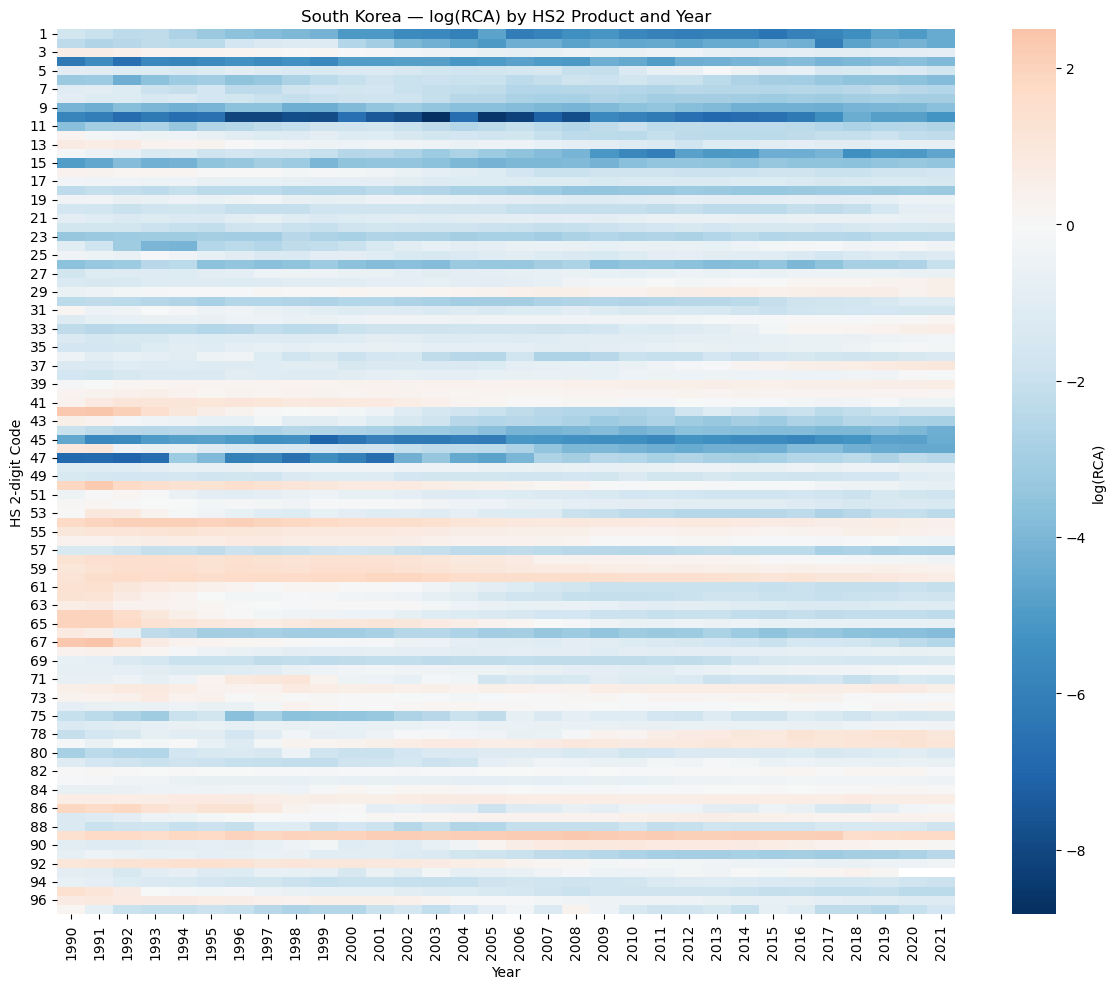

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

rca = rca_kor.copy()

# Compute log RCA (natural log)
rca["logRCA"] = np.log(rca["RCA"])

# Pivot for heatmap
heatmap_df = rca.pivot(index="cmdCode", columns="refYear", values="logRCA")

# Sort HS codes numerically
try:
    heatmap_df = heatmap_df.sort_index(key=lambda x: x.astype(int))
except:
    pass

plt.figure(figsize=(12, 10))

sns.heatmap(
    heatmap_df,
    cmap="RdBu_r",         # Diverging around zero
    center=0,              # 0 = log(RCA = 1)
    annot=False,           # can set True if you want numbers
    cbar_kws={"label": "log(RCA)"},
)


plt.title("South Korea — log(RCA) by HS2 Product and Year")
plt.xlabel("Year")
plt.ylabel("HS 2-digit Code")
plt.tight_layout()
plt.show()


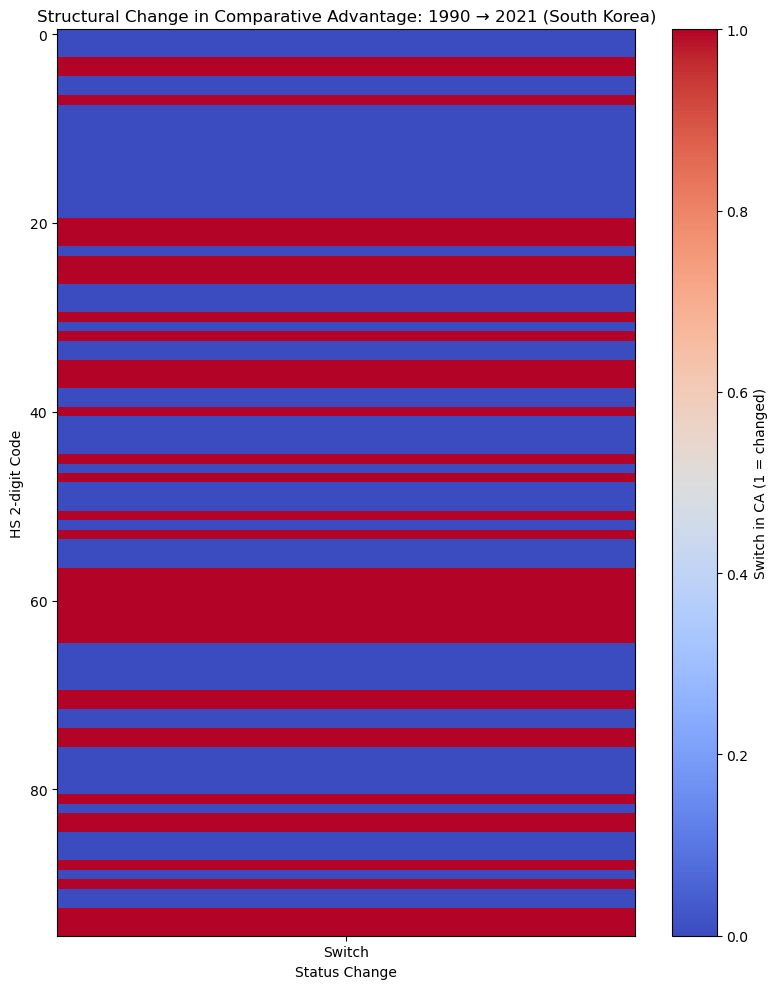

In [ ]:
df = rca_kor.copy()

# ensure numeric RCA
df["RCA"] = pd.to_numeric(df["RCA"], errors="coerce")
df["logRCA"] = np.log(df["RCA"])

# pick start & end years
start_year = 1990
end_year   = 2021

df_start = df[df["refYear"] == start_year][["cmdCode", "logRCA"]].rename(columns={"logRCA": "logRCA_start"})
df_end   = df[df["refYear"] == end_year][["cmdCode", "logRCA"]].rename(columns={"logRCA": "logRCA_end"})

change_df = df_start.merge(df_end, on="cmdCode", how="outer")

# classify comparative advantage status (RCA>1 means log>0)
change_df["start_CA"] = change_df["logRCA_start"] > 0
change_df["end_CA"]   = change_df["logRCA_end"]   > 0

# define a switch indicator
change_df["switch_CA"] = change_df["start_CA"] != change_df["end_CA"]

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
plt.imshow(change_df.set_index("cmdCode")[["switch_CA"]], aspect="auto", cmap="coolwarm")

plt.colorbar(label="Switch in RCA (1 = changed)")

plt.title("Structural Change in Comparative Advantage: 1990 → 2021 (South Korea)")
plt.xlabel("Status Change")
plt.ylabel("HS 2-digit Code")

plt.xticks([0], ["Switch"])
plt.tight_layout()
plt.show()


Saved delta table to: delta_logRCA_1990_2021.csv

Top increases (delta_logRCA):
cmdCode  logRCA_start  logRCA_end  delta_logRCA  start_CA  end_CA
     47     -6.904888   -2.441884      4.463004     False   False
     78     -2.108879    1.027648      3.136527     False    True
     33     -2.249600    0.586288      2.835888     False    True
      4     -6.317886   -3.916179      2.401707     False   False
     37     -1.368414    0.968415      2.336829     False    True
     28     -1.349194    0.470884      1.820079     False    True
     87     -1.302885    0.388646      1.691531     False    True
     80     -2.923652   -1.272056      1.651595     False   False
     26     -3.581358   -2.060466      1.520892     False   False
     38     -1.644325   -0.145475      1.498850     False   False
     15     -4.893683   -3.466833      1.426850     False   False
     35     -1.604049   -0.237248      1.366801     False   False
     30     -2.408818   -1.057173      1.351645     False   Fa

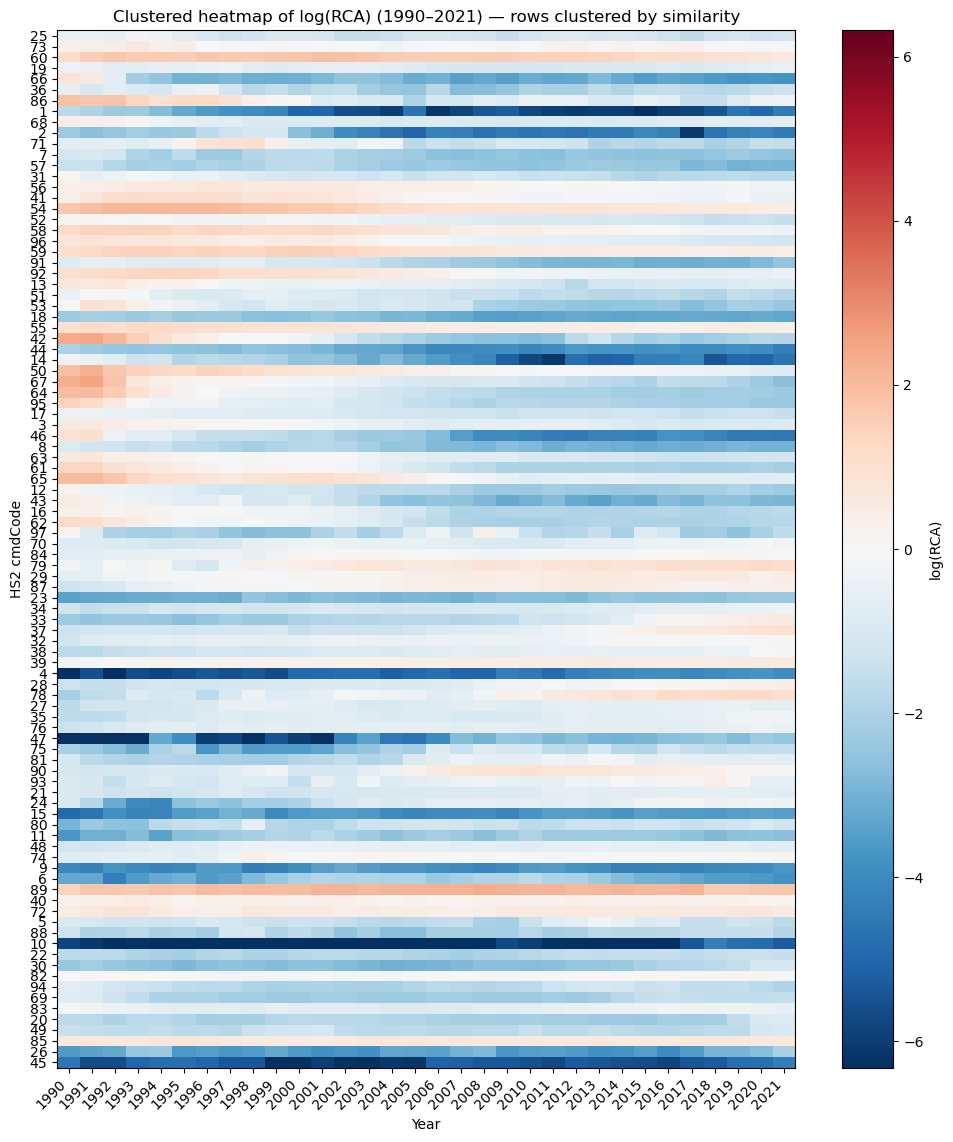

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# ---------- USER ADJUSTABLE ----------
start_year = 1990
end_year   = 2021
save_csv   = "delta_logRCA_1990_2021.csv"
topN_table = 200   # number of top rows to print for quick check (None -> print all)
# If you want the clustered heatmap to show only goods that switched (or top K by delta),
# set subset_mode = "all" / "switched" / "topK"
subset_mode = "all"
topK = 50
# -------------------------------------

# rca_kor is assumed to exist and contain columns: refYear, cmdCode, RCA
df = rca_kor.copy()   # rename as needed

# ensure numeric RCA and compute logRCA
df["RCA"] = pd.to_numeric(df["RCA"], errors="coerce")
df["logRCA"] = np.log(df["RCA"])

# --- 1) compute delta logRCA between start_year and end_year ---
df_start = df[df["refYear"] == start_year][["cmdCode", "logRCA"]].rename(columns={"logRCA": "logRCA_start"})
df_end   = df[df["refYear"] == end_year  ][["cmdCode", "logRCA"]].rename(columns={"logRCA": "logRCA_end"})

change_df = df_start.merge(df_end, on="cmdCode", how="outer")

# compute delta (end - start)
change_df["delta_logRCA"] = change_df["logRCA_end"] - change_df["logRCA_start"]

# add labels for start/end CA (True if logRCA>0)
change_df["start_CA"] = change_df["logRCA_start"] > 0
change_df["end_CA"]   = change_df["logRCA_end"]   > 0
change_df["switch_CA"] = (change_df["start_CA"] != change_df["end_CA"])

# sort by magnitude of change
change_sorted = change_df.sort_values("delta_logRCA", ascending=False).reset_index(drop=True)

# save CSV
change_sorted.to_csv(save_csv, index=False)
print(f"Saved delta table to: {save_csv}")

# print a quick top/bottom preview
n_preview = topN_table if topN_table is not None else len(change_sorted)
print("\nTop increases (delta_logRCA):")
print(change_sorted.head(n_preview)[["cmdCode", "logRCA_start", "logRCA_end", "delta_logRCA", "start_CA", "end_CA"]].to_string(index=False))

print("\nTop decreases (delta_logRCA):")
print(change_sorted.tail(n_preview)[["cmdCode", "logRCA_start", "logRCA_end", "delta_logRCA", "start_CA", "end_CA"]].iloc[::-1].to_string(index=False))

# --- 2) prepare time-series matrix of logRCA for clustering/heatmap (rows=cmdCode, cols=years) ---
years = list(range(start_year, end_year + 1))
ts = df.pivot(index="cmdCode", columns="refYear", values="logRCA")

# keep only desired year columns in order (some years may be missing -> will be NaN)
ts = ts.reindex(columns=years)

# optionally choose subset of goods:
if subset_mode == "switched":
    switched_codes = change_sorted.loc[change_sorted["switch_CA"], "cmdCode"].unique().tolist()
    ts = ts.loc[ts.index.intersection(switched_codes)]
elif subset_mode == "topK":
    top_codes = pd.concat([change_sorted.head(topK), change_sorted.tail(topK)])["cmdCode"].unique().tolist()
    ts = ts.loc[ts.index.intersection(top_codes)]
# else "all" -> keep all codes present

# drop rows with no data
ts = ts.dropna(how="all")

# --- impute missing values per-row using row mean (you can change this strategy if desired) ---
row_means = ts.mean(axis=1, skipna=True)
ts_imputed = ts.T.fillna(row_means).T  # fill NaN in each row with that row's mean

# --- standardize rows for clustering (z-score) but keep original values for color mapping ---
row_mean = ts_imputed.mean(axis=1)
row_std  = ts_imputed.std(axis=1).replace(0, 1.0)  # avoid divide-by-zero
ts_z = (ts_imputed.subtract(row_mean, axis=0)).divide(row_std, axis=0)

# --- hierarchical clustering on row z-scores ---
# compute linkage (use 'average' or 'ward' — ward needs euclidean distances)
Z = linkage(ts_z.values, method="average", metric="euclidean")
dendro = dendrogram(Z, no_plot=True)
order = dendro["leaves"]

# reorder matrix
ts_ordered = ts_imputed.iloc[order, :]

# --- clipping for visualization: set symmetric limits from 1st/99th percentiles ---
low, high = np.nanpercentile(ts_ordered.values.flatten(), [1, 99])
absmax = max(abs(low), abs(high))
vmin, vmax = -absmax, absmax

# --- Plot clustered heatmap ---
fig, ax = plt.subplots(figsize=(10, max(6, 0.12 * len(ts_ordered))))  # height scales with number of rows

cax = ax.imshow(ts_ordered.values, aspect="auto", origin="upper", vmin=vmin, vmax=vmax, cmap="RdBu_r")
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label("log(RCA)")

# ticks
# X ticks: show every year or subset if too many
xticks = range(len(years))
if len(years) > 20:
    step = max(1, len(years)//20)
    xticks = list(range(0, len(years), step))
ax.set_xticks(xticks)
ax.set_xticklabels([years[i] for i in xticks], rotation=45, ha="right")

# Y ticks: show every HS code if not too many, else sample
yticks = range(len(ts_ordered))
if len(ts_ordered) > 80:
    step_y = max(1, len(ts_ordered)//80)
    yticks = list(range(0, len(ts_ordered), step_y))
    ytick_labels = [ts_ordered.index[i] for i in yticks]
else:
    ytick_labels = ts_ordered.index.tolist()
ax.set_yticks(yticks)
ax.set_yticklabels(ytick_labels)

ax.set_xlabel("Year")
ax.set_ylabel("HS2 cmdCode")
ax.set_title(f"Clustered heatmap of log(RCA) ({start_year}–{end_year}) — rows clustered by similarity")

plt.tight_layout()
plt.show()
